In [21]:
import pandas as pd
import numpy as np

# ---------------------------------------------
#                Load dataset
# ---------------------------------------------

path = "golf_dataset/golf_dataset_wide_format.csv"
df = pd.read_csv(path)

In [22]:
# ---------------------------------------------
#               Remove features
# ---------------------------------------------

# drop all columns with "Play"
df = df.drop(columns=df.filter(like="Play").columns)

# ---------------------------------------------
#            Other transformations
# ---------------------------------------------

# convert temperature from Celsius to Fahrenheit
df["Temperature"] = (df["Temperature"] * 1.8) + 32

<Figure size 640x480 with 0 Axes>

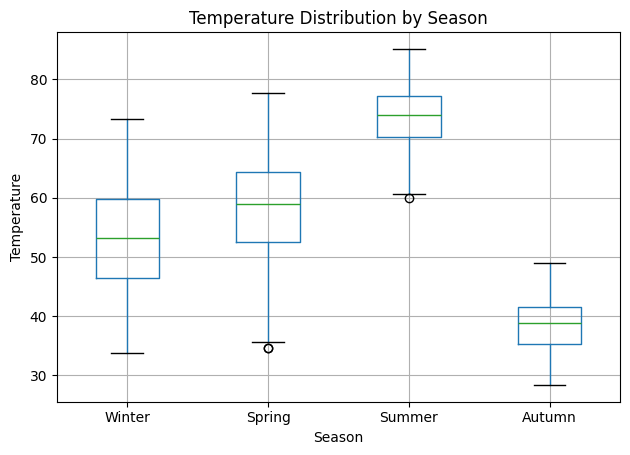

<Figure size 800x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

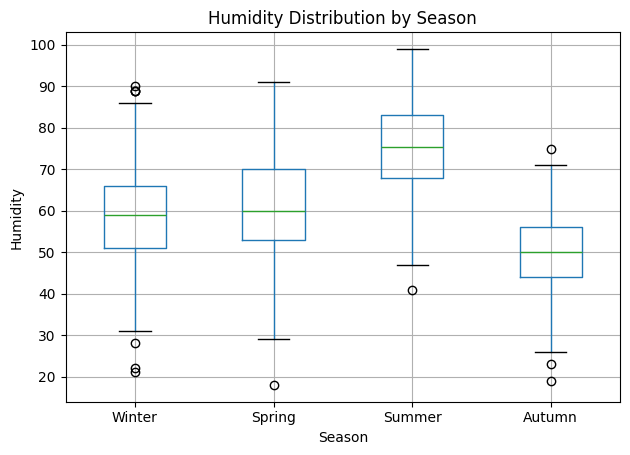

<Figure size 800x500 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt

# Assume your DataFrame is called df
# Columns: 'Season', 'Temperature', 'Humidity'

# Ensure consistent season order
season_order = ["Winter", "Spring", "Summer", "Autumn"]

# --- Temperature Boxplot ---
plt.figure()
df.boxplot(column="Temperature", by="Season")

# Reorder x-axis labels
plt.xticks(range(1, len(season_order) + 1), season_order)
plt.title("Temperature Distribution by Season")
plt.suptitle("")  # Removes automatic pandas title
plt.xlabel("Season")
plt.ylabel("Temperature")
plt.tight_layout()
plt.figure(figsize=(8, 5))
plt.show()


# --- Humidity Boxplot ---
plt.figure()
df.boxplot(column="Humidity", by="Season")

plt.xticks(range(1, len(season_order) + 1), season_order)
plt.title("Humidity Distribution by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Humidity")
plt.tight_layout()
plt.figure(figsize=(8, 5))
plt.show()

<Figure size 800x500 with 0 Axes>

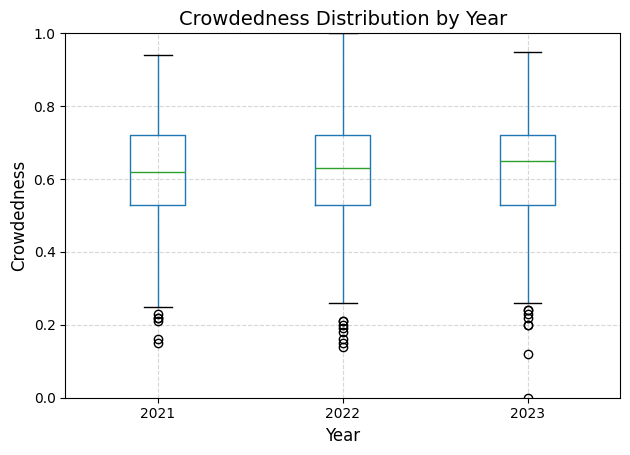

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare data ---
# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract Year
df["Year"] = df["Date"].dt.year

# Filter for specific years
df_years = df[df["Year"].isin([2021, 2022, 2023])].copy()

# Optional: enforce order
df_years["Year"] = pd.Categorical(
    df_years["Year"],
    categories=[2021, 2022, 2023],
    ordered=True
)

# --- Plot boxplots ---
plt.figure(figsize=(8, 5))

df_years.boxplot(column="Crowdedness", by="Year")

plt.title("Crowdedness Distribution by Year", fontsize=14)
plt.suptitle("")  # remove automatic title
plt.xlabel("Year", fontsize=12)
plt.ylabel("Crowdedness", fontsize=12)

plt.ylim(0.0, 1.0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

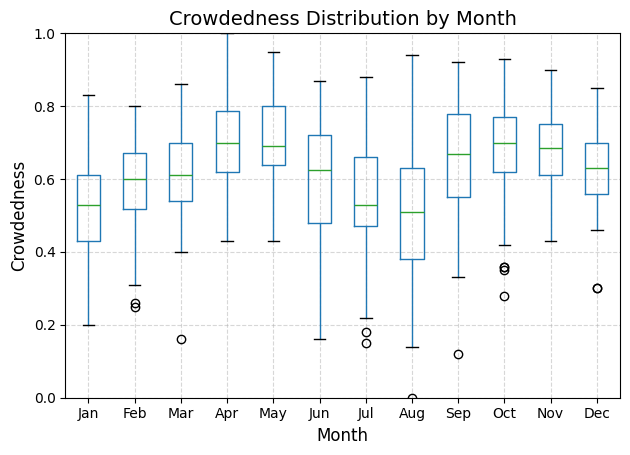

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare data ---
df["Date"] = pd.to_datetime(df["Date"])

# Extract month
df["Month"] = df["Date"].dt.month

# Ensure correct order (Jan → Dec)
month_order = list(range(1, 13))
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

# Month labels
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# --- Plot ---
plt.figure(figsize=(10, 5))

df.boxplot(column="Crowdedness", by="Month")

plt.title("Crowdedness Distribution by Month", fontsize=14)
plt.suptitle("")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Crowdedness", fontsize=12)

plt.xticks(range(1, 13), month_labels)
plt.ylim(0.0, 1.0)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

<Figure size 800x500 with 0 Axes>

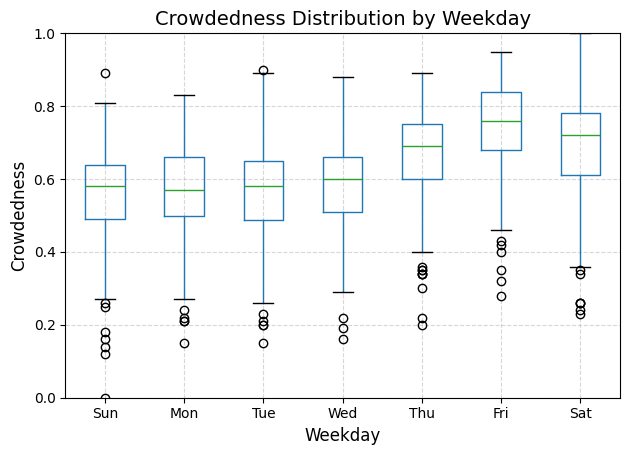

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Prepare data ---
df["Date"] = pd.to_datetime(df["Date"])

# Extract weekday (0 = Sunday, 6 = Saturday based on your dataset)
# If your dataset already has Weekday, you can skip this
# df["Weekday"] = df["Date"].dt.dayofweek  # (0=Monday in pandas, adjust if needed)

# Set correct order (Sunday → Saturday based on your definition)
weekday_order = list(range(7))
df["Weekday"] = pd.Categorical(df["Weekday"], categories=weekday_order, ordered=True)

# Labels
weekday_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

# --- Plot ---
plt.figure(figsize=(8, 5))

df.boxplot(column="Crowdedness", by="Weekday")

plt.title("Crowdedness Distribution by Weekday", fontsize=14)
plt.suptitle("")
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Crowdedness", fontsize=12)

plt.xticks(range(1, 8), weekday_labels)
plt.ylim(0.0, 1.0)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()